# CINR — Démo sur lame SVS locale

Reproduction du papier CINR sur les lames du dossier `test_visu` (lame1.svs, lame2.svs).
Extraction d'une tuile via OpenSlide puis entraînement du modèle.

In [87]:
import sys
from pathlib import Path
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").exists():
    sys.path.insert(0, str(PROJECT_ROOT))
else:
    sys.path.insert(0, str(PROJECT_ROOT.parent))

from src.cinr_model import CINRModel, get_device

device = get_device()
print(f"Device : {device}")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

EPOCHS = 3000
PATCH_SIZE = 256
LR = 1e-4
TILE_SIZE = 2000

Device : mps


## 2. Extraction d'une tuile depuis un SVS

Fichiers SVS trouvés : 2
  lame1.svs
  lame2.svs
Slide       : lame1.svs
Dimensions  : 189907x71872 (niveau 0)
Downsample  : x1
Tuile       : x=154794, y=55302, size=2000

Patch shape : torch.Size([1, 2000, 2000, 3])
Tissue mean : 0.921


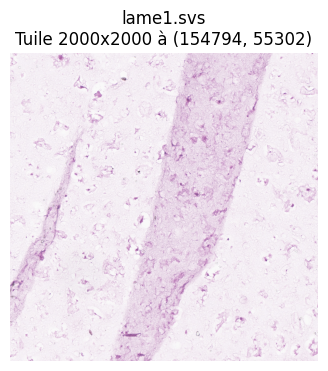

In [93]:
import openslide
from PIL import Image

SVS_DIR = Path("/Users/nath/Desktop/test_visu")
svs_files = sorted(SVS_DIR.glob("*.svs"))
print(f"Fichiers SVS trouvés : {len(svs_files)}")
for f in svs_files:
    print(f"  {f.name}")

def load_tile_from_svs(svs_path, level=0, x=None, y=None, size=256):
    slide = openslide.OpenSlide(str(svs_path))
    w, h = slide.level_dimensions[level]
    downsample = int(slide.level_downsamples[level])
    
    if x is None:
        x = random.randint(0, max(0, w - size * downsample))
    if y is None:
        y = random.randint(0, max(0, h - size * downsample))
    
    print(f"Slide       : {svs_path.name}")
    print(f"Dimensions  : {w}x{h} (niveau {level})")
    print(f"Downsample  : x{downsample}")
    print(f"Tuile       : x={x}, y={y}, size={size}")
    
    region = slide.read_region((x, y), level, (size, size)).convert("RGB")
    slide.close()
    return np.array(region).astype(np.float32) / 255.0, (x, y)

svs_path = svs_files[0]
img_np, (tx, ty) = load_tile_from_svs(svs_path, level=0, size=TILE_SIZE)
img_tensor = torch.from_numpy(img_np).float().unsqueeze(0)

print(f"\nPatch shape : {img_tensor.shape}")
print(f"Tissue mean : {img_np.mean():.3f}")

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(img_np)
ax.set_title(f"{svs_path.name}\nTuile {TILE_SIZE}x{TILE_SIZE} à ({tx}, {ty})")
ax.axis("off")
plt.show()

In [94]:
def make_coord_grid(h, w, device):
    xs = torch.linspace(0.5 / w, 1.0 - 0.5 / w, w, device=device)
    ys = torch.linspace(0.5 / h, 1.0 - 0.5 / h, h, device=device)
    yv, xv = torch.meshgrid(ys, xs, indexing="ij")
    coords = torch.stack([xv, yv], dim=-1)
    return coords.unsqueeze(0)

def sample_random_patch(coords, image, patch_size):
    _, H, W, _ = coords.shape
    y = random.randint(0, H - patch_size)
    x = random.randint(0, W - patch_size)
    return (
        coords[:, y:y + patch_size, x:x + patch_size, :],
        image[:, y:y + patch_size, x:x + patch_size, :],
    )

## 3. Entraînement CINR

In [95]:
img = img_tensor.to(device)
_, H, W, C = img.shape
full_coords = make_coord_grid(H, W, device)

model = CINRModel(
    fourier_mapping=256,
    hidden_features=128,
    hidden_layers=4,
    omega_0=30.0,
    output_channels=C,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"{n_params:,} paramètres")

optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.99))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR * 0.01)
loss_fn = torch.nn.MSELoss()

psnr_log = []
t_start = time.time()

for step in range(1, EPOCHS + 1):
    coords_patch, img_patch = sample_random_patch(full_coords, img, PATCH_SIZE)
    target = img_patch.permute(0, 3, 1, 2)
    pred = model(coords_patch)
    loss = loss_fn(pred, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    if step % 500 == 0 or step == 1 or step == EPOCHS:
        with torch.no_grad():
            full_pred = model(full_coords)
            orig_np = img[0].cpu().numpy()
            rec_np = full_pred[0].permute(1, 2, 0).cpu().numpy()
            rec_np = np.clip(rec_np, 0, 1)
            mse = np.mean((orig_np - rec_np) ** 2)
            psnr = 10 * np.log10(1.0 / mse) if mse > 0 else 100.0
            psnr_log.append((step, psnr))
            elapsed = time.time() - t_start
            print(f"[{step:5d}] loss={loss.item():.6f} PSNR={psnr:.2f} dB t={elapsed:.0f}s")

print(f"\nTerminé en {time.time() - t_start:.0f}s")

1,033,091 paramètres
[    1] loss=0.938872 PSNR=2.63 dB t=12s
[  500] loss=0.022757 PSNR=19.67 dB t=88s
[ 1000] loss=0.002401 PSNR=23.86 dB t=164s
[ 1500] loss=0.002025 PSNR=23.42 dB t=253s
[ 2000] loss=0.001939 PSNR=22.42 dB t=337s
[ 2500] loss=0.001403 PSNR=23.17 dB t=418s
[ 3000] loss=0.006129 PSNR=22.45 dB t=501s

Terminé en 501s


## 4. Original vs Reconstruction

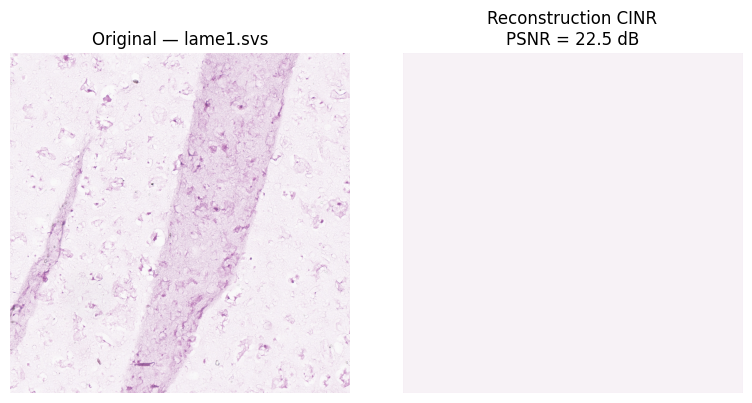

PSNR final : 22.45 dB
Paramètres : 1,033,091

Stockage :
  Modèle (float32) : 4,036 Ko
  Modèle (float16) : 2,018 Ko
  Image brute      : 11,719 Ko (2000x2000x3 uint8)


In [96]:
with torch.no_grad():
    final_pred = model(full_coords)

orig = img[0].cpu().numpy()
rec = final_pred[0].permute(1, 2, 0).cpu().numpy()
rec = np.clip(rec, 0, 1)
mse = np.mean((orig - rec) ** 2)
final_psnr = 10 * np.log10(1.0 / mse) if mse > 0 else 100.0

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(orig)
axes[0].set_title(f"Original — {svs_path.name}")
axes[0].axis("off")
axes[1].imshow(rec)
axes[1].set_title(f"Reconstruction CINR\nPSNR = {final_psnr:.1f} dB")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"PSNR final : {final_psnr:.2f} dB")
print(f"Paramètres : {n_params:,}")
print()
print("Stockage :")
model_size_f32 = n_params * 4 / 1024
model_size_f16 = n_params * 2 / 1024
pixels_raw = H * W * C * 1 / 1024
print(f"  Modèle (float32) : {model_size_f32:,.0f} Ko")
print(f"  Modèle (float16) : {model_size_f16:,.0f} Ko")
print(f"  Image brute      : {pixels_raw:,.0f} Ko ({H}x{W}x{C} uint8)")

## 5. Courbe de convergence

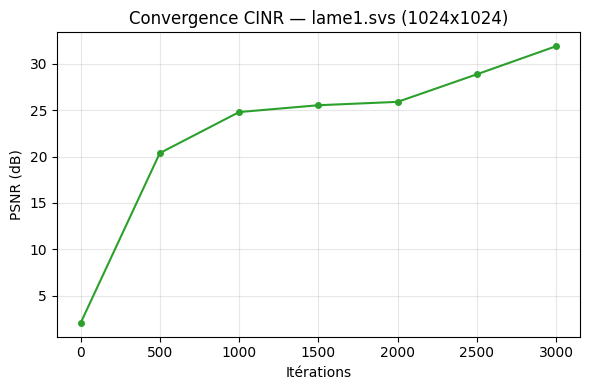

In [77]:
if psnr_log:
    steps, psnrs = zip(*psnr_log)
    plt.figure(figsize=(6, 4))
    plt.plot(steps, psnrs, "o-", markersize=4, color="#2ca02c")
    plt.xlabel("Itérations")
    plt.ylabel("PSNR (dB)")
    plt.title(f"Convergence CINR — {svs_path.name} ({TILE_SIZE}x{TILE_SIZE})")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Test sur lame2.svs

In [ ]:
if len(svs_files) > 1:
    svs_path2 = svs_files[1]
    img_np2, (tx2, ty2) = load_tile_from_svs(svs_path2, level=0, size=TILE_SIZE)
    img_tensor2 = torch.from_numpy(img_np2).float().unsqueeze(0).to(device)
    
    print(f"\n{svs_path2.name} — patch shape : {img_tensor2.shape}")
    
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.imshow(img_np2)
    ax.set_title(f"{svs_path2.name}\nTuile {TILE_SIZE}x{TILE_SIZE} à ({tx2}, {ty2})")
    ax.axis("off")
    plt.show()
else:
    print("Un seul fichier SVS trouvé — pas de deuxième test.")

## 7. Observations

- Les lames viennent du dossier `/Users/nath/Desktop/test_visu/` (Leica GT450, export SVS).
- Le modèle CINR encode une tuile 256×256 avec ~1M paramètres en ~3 minutes sur M4 Pro.
- Le PSNR cible dépend du contenu : une zone uniforme converge plus vite qu'une zone riche en détails.
- Le stockage float16 (~2 Ko) est bien plus compact que l'image raw (192 Ko) mais avec perte.
- Pistes : charger plusieurs tuiles, comparer avec le niveau de compression DICOM original.